# Projet : Prédiction de Retards de Vols


In [1]:
# Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métriques
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Configuration
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline


In [2]:
## 0. Chargement des Données

# Chemin vers le fichier (exemple avec 2021, ajustez selon vos fichiers disponibles)
file_path = 'flight-delay-dataset-20182022/Combined_Flights_2021.parquet'

try:
    df = pd.read_parquet(file_path)
    print(f"Dataset chargé. Shape initial : {df.shape}")
    
    # ECHANTILLONNAGE (Optionnel mais recommandé pour le dev interactif)
    # On garde 100 000 lignes pour accélérer les calculs (PCA, Random Forest)
    df = df.sample(n=100000, random_state=42).reset_index(drop=True)
    print(f"Dataset échantillonné. Shape : {df.shape}")
except Exception as e:
    print(f"Erreur lors du chargement : {e}")
    # Fallback si le fichier n'existe pas, créer un dummy df pour éviter les erreurs suivantes
    if 'df' not in locals():
        print("Création d'un DataFrame dummy pour structure.")
        df = pd.DataFrame()

df.head()


Dataset chargé. Shape initial : (6311871, 61)
Dataset échantillonné. Shape : (100000, 61)


,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2021-10-31,Southwest Airlines Co.,FLL,MSY,False,False,1725,1759.0,34.0,34.0,1856.0,26.0,98.0,125.0,117.0,674.0,2021,4,10,31,7,WN,WN,19393,WN,4545,WN,19393,WN,N210WN,4545,11697,1169706,32467,"Fort Lauderdale, FL",FL,12,Florida,33,13495,1349505,33495,"New Orleans, LA",LA,22,Louisiana,72,1.0,2.0,1700-1759,14.0,1813.0,1851.0,5.0,1830,26.0,1.0,1.0,1800-1859,3,0.0
1,2021-12-25,"Commutair Aka Champlain Enterprises, Inc.",DEN,DIK,False,False,1850,1845.0,0.0,-5.0,2034.0,0.0,72.0,107.0,109.0,488.0,2021,4,12,25,6,UA,UA_CODESHARE,19977,UA,4263,C5,20445,C5,N21154,4263,11292,1129202,30325,"Denver, CO",CO,8,Colorado,82,11315,1131502,31315,"Dickinson, ND",ND,38,North Dakota,66,0.0,-1.0,1800-1859,27.0,1912.0,2024.0,10.0,2037,-3.0,0.0,-1.0,2000-2059,2,0.0
2,2021-10-10,Air Wisconsin Airlines Corp,ROA,IAD,True,False,1030,NaN,NaN,NaN,NaN,NaN,NaN,68.0,NaN,177.0,2021,4,10,10,7,UA,UA_CODESHARE,19977,UA,3876,ZW,20046,ZW,None,3876,14574,1457405,34574,"Roanoke, VA",VA,51,Virginia,38,12264,1226402,30852,"Washington, DC",VA,51,Virginia,38,NaN,NaN,1000-1059,NaN,NaN,NaN,NaN,1138,NaN,NaN,NaN,1100-1159,1,0.0
3,2021-04-01,American Airlines Inc.,SAN,DFW,False,False,723,755.0,32.0,32.0,1235.0,5.0,138.0,187.0,160.0,1171.0,2021,2,4,1,4,AA,AA,19805,AA,1952,AA,19805,AA,N563UW,1952,14679,1467903,33570,"San Diego, CA",CA,6,California,91,11298,1129806,30194,"Dallas/Fort Worth, TX",TX,48,Texas,74,1.0,2.0,0700-0759,14.0,809.0,1227.0,8.0,1230,5.0,0.0,0.0,1200-1259,5,0.0
4,2021-08-09,Delta Air Lines Inc.,SMF,SLC,False,False,1359,1412.0,13.0,13.0,1646.0,12.0,77.0,95.0,94.0,532.0,2021,3,8,9,1,DL,DL,19790,DL,2906,DL,19790,DL,N334NW,2906,14893,1489302,33192,"Sacramento, CA",CA,6,California,91,14869,1486903,34614,"Salt Lake City, UT",UT,49,Utah,87,0.0,0.0,1300-1359,13.0,1425.0,1642.0,4.0,1634,12.0,0.0,0.0,1600-1659,3,0.0


## Étape 1 : Data Exploratory Analysis (EDA) & Exploration Non Supervisée


Distribution de la target (ArrDel15) :
ArrDel15
0.0    0.82747
1.0    0.17253
Name: proportion, dtype: float64


/var/folders/cd/77zy425s78v6g5pk7g9r_gt40000gn/T/ipykernel_75728/1172031570.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


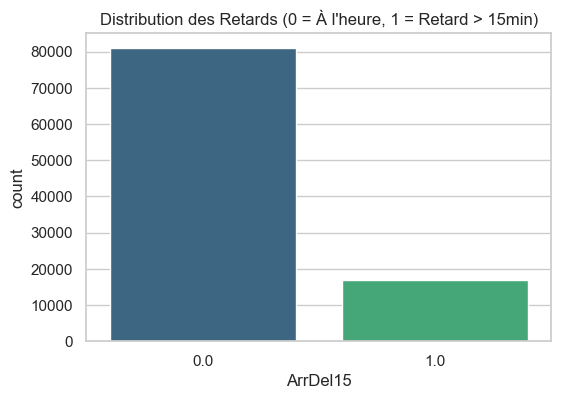

In [3]:
# 1.1 Nettoyage Rapide
# Conversion de FlightDate en datetime
if 'FlightDate' in df.columns:
    df['FlightDate'] = pd.to_datetime(df['FlightDate'])
    
    # Extraction des infos temporelles (si pas déjà présentes ou pour être sûr)
    df['Month'] = df['FlightDate'].dt.month
    df['DayOfWeek'] = df['FlightDate'].dt.dayofweek  # 0 = Lundi, 6 = Dimanche

# 1.2 Analyse de la Target
target_col = 'ArrDel15'
if target_col in df.columns:
    print("Distribution de la target (ArrDel15) :")
    print(df[target_col].value_counts(normalize=True))
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_col, data=df, palette='viridis')
    plt.title('Distribution des Retards (0 = À l\'heure, 1 = Retard > 15min)')
    plt.show()


/var/folders/cd/77zy425s78v6g5pk7g9r_gt40000gn/T/ipykernel_75728/738225319.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=airline_delay.index, x=airline_delay.values, palette='coolwarm')


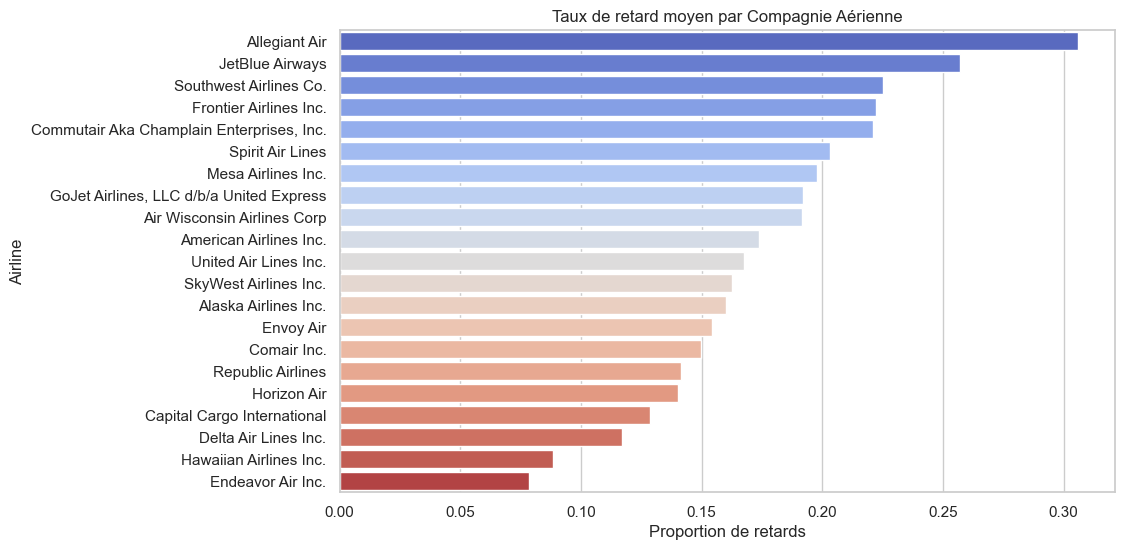

/var/folders/cd/77zy425s78v6g5pk7g9r_gt40000gn/T/ipykernel_75728/738225319.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Month', y=target_col, data=df, ax=ax[0], ci=None, palette='magma',)
/var/folders/cd/77zy425s78v6g5pk7g9r_gt40000gn/T/ipykernel_75728/738225319.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y=target_col, data=df, ax=ax[0], ci=None, palette='magma',)
/var/folders/cd/77zy425s78v6g5pk7g9r_gt40000gn/T/ipykernel_75728/738225319.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='DayOfWeek', y=target_col, data=df, ax=ax[1], ci=None, palette='magma')
/var/folders/cd/77zy425s78v6g5pk7g9r_gt40000gn/T/ipykernel_75728/738225319.py:19: FutureWarning: 

Passing `palette` without as

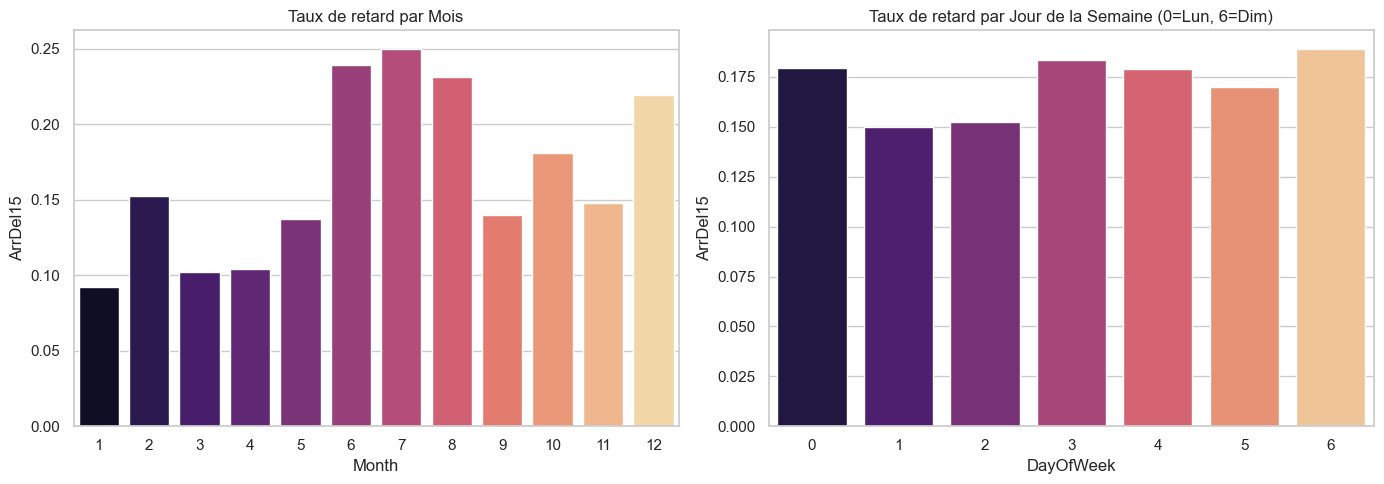

In [4]:
# 1.3 Visualisation Univariée & Bivariée
if 'Airline' in df.columns and target_col in df.columns:
    # Taux de retard par Airline
    airline_delay = df.groupby('Airline')[target_col].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(y=airline_delay.index, x=airline_delay.values, palette='coolwarm')
    plt.title('Taux de retard moyen par Compagnie Aérienne')
    plt.xlabel('Proportion de retards')
    plt.show()

if 'Month' in df.columns and target_col in df.columns:
    # Taux de retard par Month et DayOfWeek
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.barplot(x='Month', y=target_col, data=df, ax=ax[0], ci=None, palette='magma',)
    ax[0].set_title('Taux de retard par Mois')
    
    sns.barplot(x='DayOfWeek', y=target_col, data=df, ax=ax[1], ci=None, palette='magma')
    ax[1].set_title('Taux de retard par Jour de la Semaine (0=Lun, 6=Dim)')
    
    plt.tight_layout()
    plt.show()


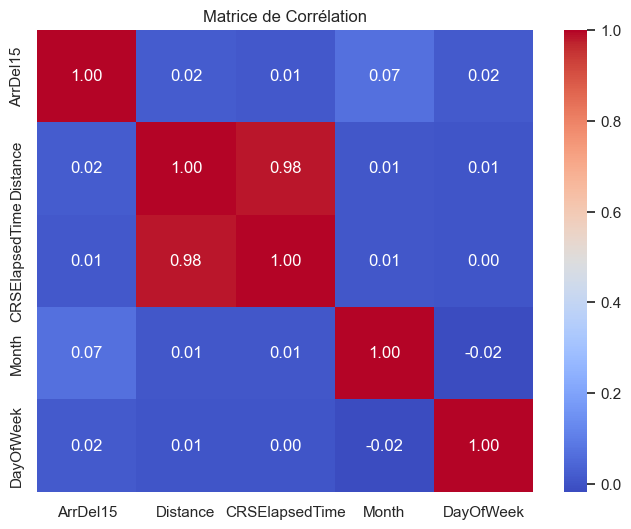

In [5]:
# 1.4 Corrélation (Variables numériques)
# Sélection de quelques variables numériques clés
cols_num_corr = ['ArrDel15', 'Distance', 'CRSElapsedTime', 'Month', 'DayOfWeek']
# On vérifie qu'elles sont dans le DF
cols_num_corr = [c for c in cols_num_corr if c in df.columns]

if cols_num_corr:
    corr_matrix = df[cols_num_corr].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Matrice de Corrélation')
    plt.show()


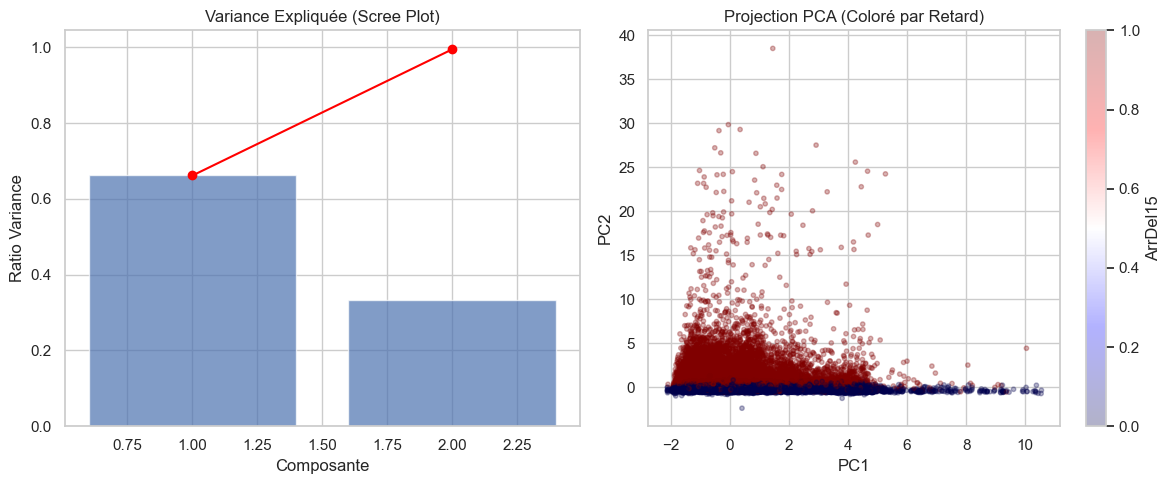

In [6]:
# 1.5 Exploration Non Supervisée (PCA)

# Sélection features numériques pour la PCA
# On ne prend PAS la target, et on évite les fuites (bien que ce soit de l'explo)
features_pca = ['DepDelay', 'Distance', 'CRSElapsedTime']
features_pca = [c for c in features_pca if c in df.columns]

if features_pca and target_col in df.columns:
    # Préparation des données (Drop NaNs pour PCA)
    df_pca = df[features_pca + [target_col]].dropna()
    X_pca = df_pca[features_pca]
    y_pca = df_pca[target_col]
    
    # Standardisation
    scaler_pca = StandardScaler()
    X_scaled_pca = scaler_pca.fit_transform(X_pca)
    
    # PCA (2 composantes)
    pca = PCA(n_components=2)
    X_proj = pca.fit_transform(X_scaled_pca)
    
    # Scree Plot
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.7)
    plt.plot(range(1, 3), np.cumsum(pca.explained_variance_ratio_), marker='o', color='red')
    plt.title('Variance Expliquée (Scree Plot)')
    plt.xlabel('Composante')
    plt.ylabel('Ratio Variance')
    
    # Projection 2D
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_proj[:, 0], X_proj[:, 1], c=y_pca, cmap='seismic', alpha=0.3, s=10)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Projection PCA (Coloré par Retard)')
    plt.colorbar(scatter, label='ArrDel15')
    
    plt.tight_layout()
    plt.show()


## Étape 2 : Preprocessing & Train-Test Split


In [16]:
# 2.1 Gestion des NaNs et du Data Leakage

# Liste des colonnes à exclure (Data Leakage : info connue après atterrissage)
# On définit nos features explicites pour éviter d'inclure des trucs par erreur
features_num = [ 'Distance', 'CRSElapsedTime', 'Month', 'DayOfWeek']
features_cat = ['Airline', 'Origin', 'Dest']

# Vérification présence colonnes
features_num = [c for c in features_num if c in df.columns]
features_cat = [c for c in features_cat if c in df.columns]

if features_num and features_cat and target_col in df.columns:
    # Sélectionner uniquement les colonnes utiles
    data = df[features_num + features_cat + [target_col]].copy()
    
    # Gestion des NaNs
    # On drop les lignes où la Target est manquante
    data = data.dropna(subset=[target_col])
    
    # Pour les features, stratégie simple : Drop (vu la taille du dataset)
    print(f"NaNs avant drop : \n{data.isna().sum().sum()}")
    data = data.dropna()
    print(f"Shape après nettoyage NaNs : {data.shape}")
    
    X = data[features_num + features_cat]
    y = data[target_col]
    
    # 2.2 Split Train-Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    print(f"Train set : {X_train.shape}")
    print(f"Test set : {X_test.shape}")


NaNs avant drop : 
0
Shape après nettoyage NaNs : (97896, 8)
Train set : (78316, 7)
Test set : (19580, 7)


In [17]:
# 2.3 Pipeline de Preprocessing

if 'X_train' in locals():
    # Standardisation pour les numériques
    # OneHotEncoder pour les catégorielles
    # sparse_output=False pour compatibilité (attention mémoire si dataset géant sans sampling)
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), features_num),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
        ]
    )


## Étape 3 : Modélisation (Baseline vs Ensemble)


In [18]:
# 3.1 Modèle Baseline : Logistic Regression

if 'X_train' in locals():
    pipeline_lr = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])
    
    print("Entraînement Logistic Regression...")
    pipeline_lr.fit(X_train, y_train)
    
    # Prédictions
    y_pred_lr = pipeline_lr.predict(X_test)
    
    # Métriques
    print("\n--- Logistic Regression Metrics ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
    print(f"F1-Score : {f1_score(y_test, y_pred_lr):.4f}")
    print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred_lr))


Entraînement Logistic Regression...

--- Logistic Regression Metrics ---
Accuracy : 0.8273
F1-Score : 0.0035
Confusion Matrix :
 [[16193     9]
 [ 3372     6]]


In [19]:
# 3.2 Modèle Ensemble : Random Forest Classifier

if 'X_train' in locals():
    # On limite n_estimators et max_depth pour la rapidité de l'exemple
    pipeline_rf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1))
    ])
    
    print("Entraînement Random Forest...")
    pipeline_rf.fit(X_train, y_train)
    
    # Prédictions
    y_pred_rf = pipeline_rf.predict(X_test)
    
    # Métriques
    print("\n--- Random Forest Metrics ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
    print(f"F1-Score : {f1_score(y_test, y_pred_rf):.4f}")
    print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred_rf))


Entraînement Random Forest...

--- Random Forest Metrics ---
Accuracy : 0.8275
F1-Score : 0.0006
Confusion Matrix :
 [[16202     0]
 [ 3377     1]]


                 Model  Accuracy  F1-Score
0  Logistic Regression  0.827324  0.003537
1        Random Forest  0.827528  0.000592


/var/folders/cd/77zy425s78v6g5pk7g9r_gt40000gn/T/ipykernel_75728/1474795045.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=results, palette='viridis')


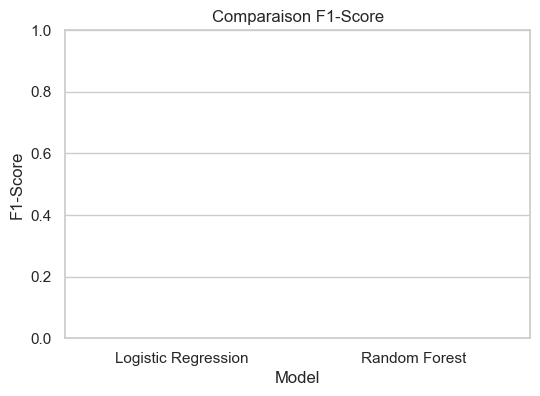

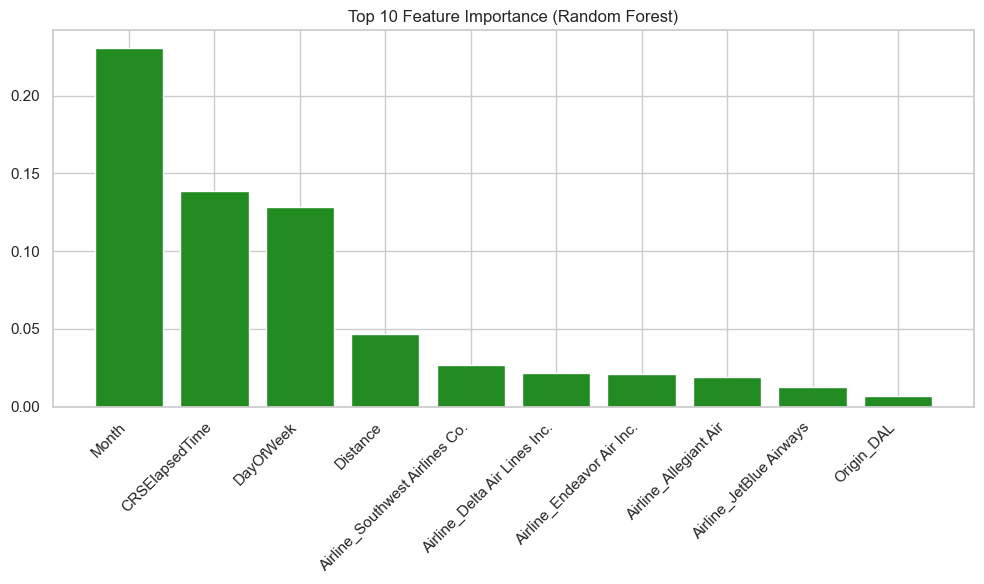

In [20]:
# 3.3 Comparaison et Feature Importance

if 'y_pred_lr' in locals() and 'y_pred_rf' in locals():
    # Tableau Comparatif
    results = pd.DataFrame({
        'Model': ['Logistic Regression', 'Random Forest'],
        'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
        'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)]
    })
    
    print(results)
    
    plt.figure(figsize=(6, 4))
    sns.barplot(x='Model', y='F1-Score', data=results, palette='viridis')
    plt.title('Comparaison F1-Score')
    plt.ylim(0, 1)
    plt.show()
    
    # Feature Importance (Random Forest)
    rf_model = pipeline_rf.named_steps['classifier']
    preproc_step = pipeline_rf.named_steps['preprocessor']
    
    try:
        # Récupération des noms des features après encodage
        cat_names = preproc_step.named_transformers_['cat'].get_feature_names_out(features_cat)
        all_features = features_num + list(cat_names)
        
        importances = rf_model.feature_importances_
        # Top 10
        indices = np.argsort(importances)[::-1][:10] 
        
        plt.figure(figsize=(10, 6))
        plt.bar(range(10), importances[indices], align='center', color='forestgreen')
        plt.xticks(range(10), [all_features[i] for i in indices], rotation=45, ha='right')
        plt.title('Top 10 Feature Importance (Random Forest)')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Impossible d'afficher les features importance: {e}")
